In [1]:
import numpy as np
import matplotlib.pyplot as plt
from regions import Regions
import regions
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
import pandas as pd

from sklearn.mixture import GaussianMixture

from smart_plotters.jwst_plots import JWSTCatalog, make_cat_use, make_brick_cat

from dust_extinction.averages import CT06_MWGC, RRP89_MWGC

In [46]:
distance = 8.1 * u.kpc
rad_ang = 0.03 * u.deg

physize = distance * np.tan(rad_ang.to(u.rad))
physize.to(u.pc)

<Quantity 4.24115047 pc>

In [49]:
dAvdr = 0.002 / u.pc
magerr = 0.1

dist_res = magerr / dAvdr
dist_res

<Quantity 50. pc>

In [54]:
r = 100 * u.pc 
d = 56 * u.pc
chord_l = 2 * np.sqrt(r**2 - (d/2)**2)
chord_l/2

<Quantity 96. pc>

In [10]:
cat_use = make_cat_use()

# How good is Gaussian Mixture at Separating the RC More Generally?

In [2]:
area = 0.1 * u.deg**2
area.to(u.arcsec**2)

<Quantity 1296000. arcsec2>

In [19]:
trilegal_fn = '/home/savannahgramze/orange_link/adamginsburg/jwst/cloudc/trilegal/trilegal_nircam.dat'
trilegal = pd.read_csv(trilegal_fn, sep='\s+', header=0)#, nrows=10000000)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/scratch/local/18841064/ipykernel_2293513/4003678675.py:2: SyntaxWarning: invalid escape sequence '\s'
  trilegal = pd.read_csv(trilegal_fn, sep='\s+', header=0)#, nrows=10000000)


In [20]:
def get_A_lambda(wavelength, Av, ext=CT06_MWGC()):
    return Av * ext(wavelength)

def apply_extinction(trilegal, ext=CT06_MWGC(), factor=1.0):
    dAvdr = 0.002 / u.pc # units of magnitude/pc

    distance = 10**(trilegal['m-M0']/5 + 1)

    trilegal['distance'] = distance

    trilegal['Av'] = Av =  dAvdr * distance * factor

    # Apply extinction law
    trilegal['eF182M'] = trilegal['F182M'] + get_A_lambda(1.82*u.um, Av, ext=ext)
    trilegal['eF210M'] = trilegal['F210M'] + get_A_lambda(2.10*u.um, Av, ext=ext)
    trilegal['eF410M'] = trilegal['F410M'] + get_A_lambda(4.10*u.um, Av, ext=ext)
    trilegal['eF460M'] = trilegal['F460M'] + get_A_lambda(4.60*u.um, Av, ext=ext)

apply_extinction(trilegal, ext=CT06_MWGC(), factor=1)

trilegal = trilegal[(trilegal['eF182M'] < 20) & (trilegal['eF182M'] > 13)]

In [21]:
cat_use.catalog = cat_use.catalog[(cat_use.band('F182M') < 20) & (cat_use.band('F182M') > 13)]

In [22]:
trilegal.columns

Index(['#Gc', 'logAge', '[M/H]', 'm_ini', 'logL', 'logTe', 'logg', 'm-M0',
       'Av', 'm2/m1', 'mbol', 'F070W', 'F090W', 'F115W', 'F150W', 'F200W',
       'F277W', 'F356W', 'F444W', 'F150W2', 'F322W2', 'F140M', 'F162M',
       'F182M', 'F210M', 'F250M', 'F300M', 'F335M', 'F360M', 'F410M', 'F430M',
       'F460M', 'F480M', 'F150WS60', 'Mact', 'distance', 'eF182M', 'eF210M',
       'eF410M', 'eF460M'],
      dtype='object')

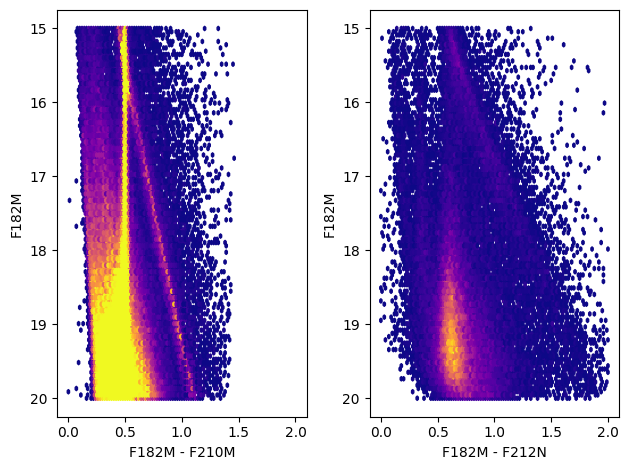

In [25]:
ax = plt.subplot(121)
ax.hexbin(trilegal['eF182M'] - trilegal['eF210M'], trilegal['eF182M'], gridsize=100, mincnt=1, cmap='plasma', extent=[0,2,15,20], vmax=100)
ax.set_xlabel('F182M - F210M')
ax.set_ylabel('F182M')
plt.gca().invert_yaxis()

ax = plt.subplot(122)
ax.hexbin(cat_use.color('F182M','F212N'), cat_use.band('F182M'), gridsize=100, mincnt=1, cmap='plasma', extent=[0,2,15,20])
ax.set_xlabel('F182M - F212N')
ax.set_ylabel('F182M')
plt.gca().invert_yaxis()

plt.tight_layout()  

In [34]:
mask_tri_nonan = np.isfinite(trilegal['eF182M']) & np.isfinite(trilegal['eF210M']) & np.isfinite(trilegal['eF410M']) & np.isfinite(trilegal['eF460M'])
tri_columns = ['eF182M', 'eF210M', 'eF410M', 'eF460M', 'eF182M - eF210M', 'eF182M - eF410M']
trilegal['eF182M - eF210M'] = trilegal['eF182M'] - trilegal['eF210M']
trilegal['eF182M - eF410M'] = trilegal['eF182M'] - trilegal['eF410M']
samp_tri = trilegal[mask_tri_nonan][tri_columns].to_numpy()

In [35]:
samp_tri.T.shape

(6, 458498)

In [36]:
model = GaussianMixture(n_components=6, n_init=10, random_state=0)

In [37]:
model.fit(samp_tri)

GaussianMixture(n_components=6, n_init=10, random_state=0)

In [ ]:
def plot_gmm_results(model, data, x_col, ycol, colnames, inverty=False, **kwargs):
    fig, ax = plt.subplots(figsize=(6,6))

    ax.scatter(data[:, x_col], data[:, ycol], c=model.predict(data), **kwargs)
    #ax.scatter(model.means_[:, x_col], model.means_[:, ycol], c='red', s=200, alpha=0.5)

    ax.set_xlabel(colnames[x_col])
    ax.set_ylabel(colnames[ycol])
    if inverty:
        plt.gca().invert_yaxis()

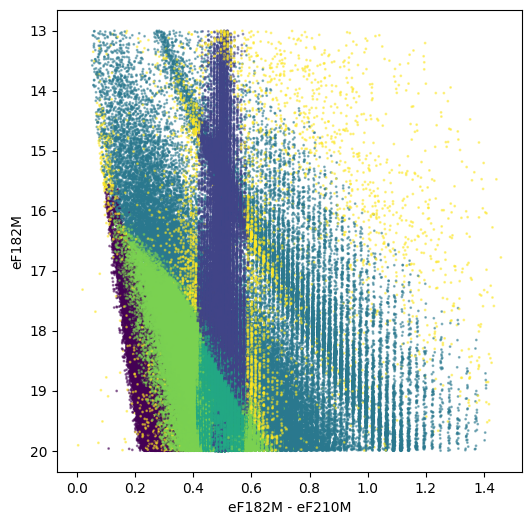

In [39]:
plot_gmm_results(model, samp_tri, 4, 0, tri_columns, inverty=True, s=1, alpha=0.5)

In [40]:
def plot_feature_results(model, data, columns):
    fig, axs = plt.subplots(len(columns), len(columns), figsize=(15, 15))
    for i in range(len(columns)):
        for j in range(len(columns)):
            axs[i, j].scatter(data[:, i], data[:, j], s=1, alpha=0.5, c=model.predict(data), cmap='rainbow')
            axs[i, j].set_xlabel(columns[i])
            axs[i, j].set_ylabel(columns[j])
    plt.tight_layout()

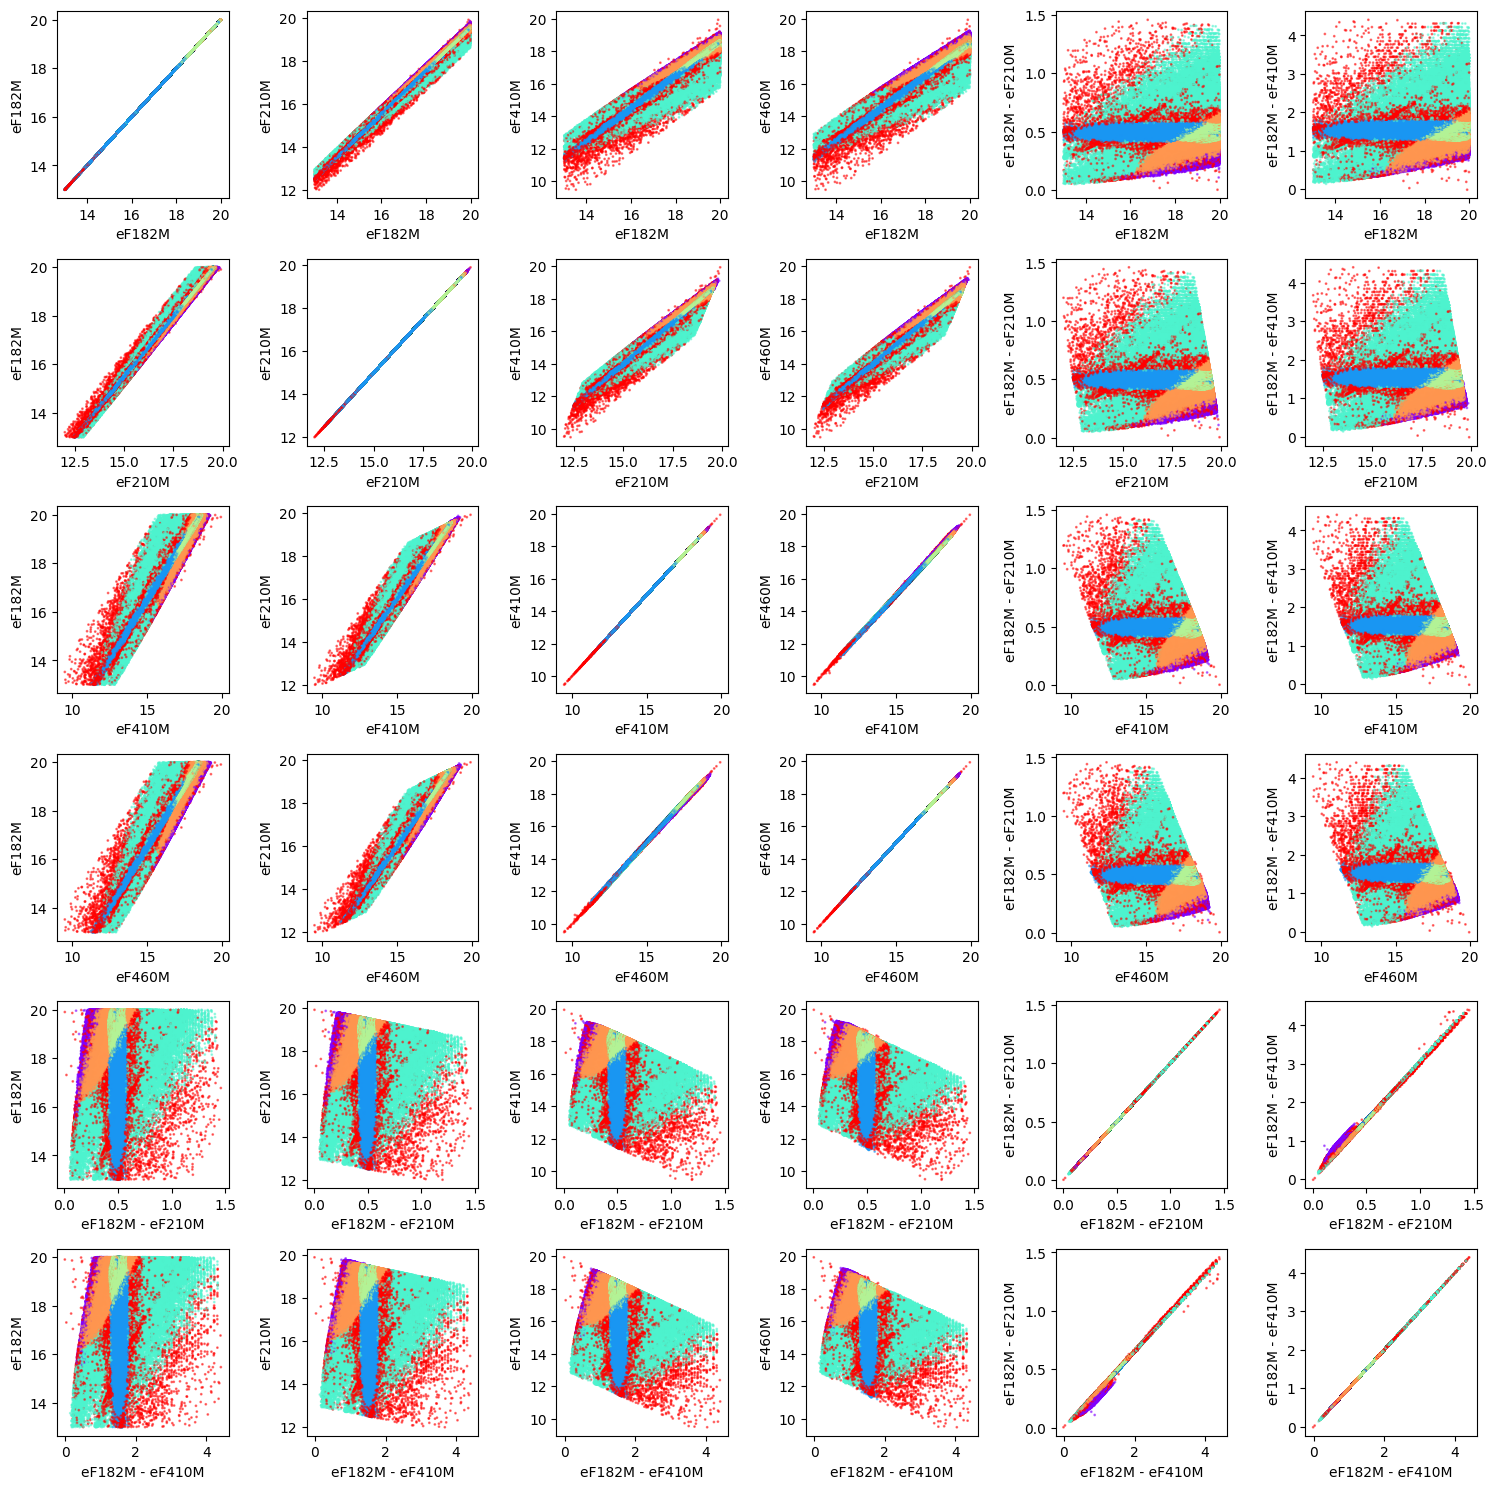

In [41]:
plot_feature_results(model, samp_tri, tri_columns)